# Import libraries.

In [574]:
import warnings
warnings.simplefilter('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

### Let's read and see what a dataset consists of.

In [617]:
df = pd.read_csv('European_Ski_Resorts.csv')

In [609]:
df.head()

,Resort,Country,HighestPoint,LowestPoint,Price,TotalSlope,Snowparks,NightSki,Lifts,LiftCapacity,SnowCannons,NightSki & Snowparks
0,Alpendorf (Ski amedé),Austria,1980,740,52,115,Yes,No,49,75398,600,NoYes
1,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,Andorra,2640,1710,47,210,Yes,Yes,72,99017,1032,YesYes
2,Oberau (Wildschönau),Austria,1130,900,30,2,No,No,2,1932,0,NoNo
3,Dachstein West,Austria,1620,780,42,51,Yes,Yes,36,32938,163,YesYes
4,Rosa Khutor,Southern Russia,2320,940,22,77,Yes,No,27,49228,450,NoYes


In [581]:
df.tail()

,Unnamed: 0,Resort,Country,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,Snowparks,NightSki,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons
371,372,Montgenèvre (Via Lattea),France,2749,1372,48,96,220,84,400,No,Yes,29,35,7,71,96433,0
372,373,Sauze d’Oulx (Via Lattea),Italy,2749,1372,48,96,220,84,400,No,Yes,29,35,7,71,96433,0
373,374,Gressoney - La-Trinite (Monterosa Ski),Italy,3275,1212,43,23,94,15,132,Yes,No,9,9,12,30,31984,655
374,375,Champoluc (Monterosa Ski),Italy,3275,1212,43,23,94,15,132,Yes,No,9,9,12,30,31984,655
375,376,Zauchensee,Austria,2188,1000,52,23,16,4,44,Yes,No,9,6,4,19,25988,113


## Dataset in Russian:
For those who struggle with English, I decided to translate the summary of this dataset for more profound comprehention of information.
*   Resort: Название горнолыжного и сноубордического курорта.
*   Country: Название страны, в которой находится курорт.
*   HighestPoint: Самая высокая точка горы на горнолыжном курорте.(в метрах)
*   LowestPoint: Самая низкая точка катания на горнолыжном курорте.(в метрах)
*   DayPassPriceAdult: Цена показывает, сколько стоит 1 взрослый на 1 день в основной сезон (в евро).
*   BeginnerSlope: Общее количество «начинающих» трасс в километрах на курорте.
*   IntermediateSlope: Общее количество «промежуточных» склонов в километрах на курорте.
*   DifficultSlope	: Общее количество «сложных» трасс в километрах на курорте.
*   TotalSlope: Сумма «трасс для начинающих» + «промежуточных трасс» + «сложных трасс»
*   Snowparks: Есть ли на курорте один или несколько сноупарков или нет.
*   NightSki: Есть ли на курорте один или несколько сноупарков или нет.
*   SurfaceLifts: Количество подъемников в этой категории: T-bar, Sunkidslift, Канатные подъемники.
*   ChairLifts: Общее количество кресельных подъемников.
*   GondolaLifts: Количество подъемников в этой категории: Гондола, Фуникулер и тд.
*   TotalLifts: Сумма «наземные лифты и т.д.» + «гондольные и т.д.» + «кресельные подъемники и т.д.»
*   LiftCapacity: Сколько пассажиров может обслужить система подъемников на горнолыжном курорте за один час.
*   SnowCannons: Общее количество снежных пушек на горнолыжном курорте.
*   [Сам датасет](https://www.kaggle.com/datasets/thomasnibb/european-ski-resorts)


### The main dataset statistics.

In [584]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         376 non-null    int64 
 1   Resort             376 non-null    object
 2   Country            376 non-null    object
 3   HighestPoint       376 non-null    int64 
 4   LowestPoint        376 non-null    int64 
 5   DayPassPriceAdult  376 non-null    int64 
 6   BeginnerSlope      376 non-null    int64 
 7   IntermediateSlope  376 non-null    int64 
 8   DifficultSlope     376 non-null    int64 
 9   TotalSlope         376 non-null    int64 
 10  Snowparks          376 non-null    object
 11  NightSki           376 non-null    object
 12  SurfaceLifts       376 non-null    int64 
 13  ChairLifts         376 non-null    int64 
 14  GondolaLifts       376 non-null    int64 
 15  TotalLifts         376 non-null    int64 
 16  LiftCapacity       376 non-null    int64 
 1


### We will input only data with numerical values and, for better visualization, convert percentages.

In [587]:
df.describe(percentiles = [0.1,0.9,0.2,0.3],include = 'number')

,Unnamed: 0,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons
count,376,376,376,376,376,376,376,376,376,376,376,376,376,376
mean,188,2052,1055,41,36,38,12,86,14,9,4,27,34727,218
std,109,777,424,12,54,50,18,114,14,13,7,31,45955,407
min,1,0,0,0,0,0,0,0,0,0,0,0,0,0
10%,38,1000,571,26,3,3,0,8,3,1,0,5,4312,0
20%,76,1370,702,31,6,7,1,20,4,2,0,9,7700,0
30%,114,1689,821,35,10,11,3,29,6,3,0,11,12456,0
50%,188,2104,1050,42,19,22,5,48,9,5,2,17,19032,54
90%,338,3019,1600,54,96,90,30,210,29,22,11,64,86618,642
max,376,3899,2180,81,312,239,103,600,89,74,40,174,252280,2383



Note that most numerical values have unnecessary zeros after the decimal point. We will remove these redundant zeros for data analysis.

In [590]:
pd.options.display.float_format = '{:.0f}'.format
df.describe(percentiles = [0.1,0.9,0.2,0.3],include = 'number')

,Unnamed: 0,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons
count,376,376,376,376,376,376,376,376,376,376,376,376,376,376
mean,188,2052,1055,41,36,38,12,86,14,9,4,27,34727,218
std,109,777,424,12,54,50,18,114,14,13,7,31,45955,407
min,1,0,0,0,0,0,0,0,0,0,0,0,0,0
10%,38,1000,571,26,3,3,0,8,3,1,0,5,4312,0
20%,76,1370,702,31,6,7,1,20,4,2,0,9,7700,0
30%,114,1689,821,35,10,11,3,29,6,3,0,11,12456,0
50%,188,2104,1050,42,19,22,5,48,9,5,2,17,19032,54
90%,338,3019,1600,54,96,90,30,210,29,22,11,64,86618,642
max,376,3899,2180,81,312,239,103,600,89,74,40,174,252280,2383


Now our description looks much neater and more readable.

## Let's check if we have lines with NaN. If not, we leave everything as it is, if yes, we remove them.

In [594]:
df.isna().sum()

Unnamed: 0           0
Resort               0
Country              0
HighestPoint         0
LowestPoint          0
DayPassPriceAdult    0
BeginnerSlope        0
IntermediateSlope    0
DifficultSlope       0
TotalSlope           0
Snowparks            0
NightSki             0
SurfaceLifts         0
ChairLifts           0
GondolaLifts         0
TotalLifts           0
LiftCapacity         0
SnowCannons          0
dtype: int64

### Analysing the information above we understand that we have no rows with NaN.

### Let's remove columns unnecessary for analysis, sort by price and number of slides, and replace the names of some columns for convenience. Also let's add a column that determines whether the resort simultaneously offers night skiing and snow parks.

In [619]:
df = df.drop(['BeginnerSlope','IntermediateSlope','DifficultSlope','SurfaceLifts', 'ChairLifts', 'GondolaLifts', 'Unnamed: 0'],  axis=1)
df.sort_values(['DayPassPriceAdult', 'TotalSlope'], ascending = False)
df.rename(columns={'DayPassPriceAdult': 'Price', 'TotalLifts': 'Lifts'}, inplace=True)
df['NightSki & Snowparks'] = df['NightSki'] + df['Snowparks']
df['NightSki & Snowparks']=df['NightSki & Snowparks'].replace('YesYes', 'Yes')
df['NightSki & Snowparks']=df['NightSki & Snowparks'].replace('NoNo', 'No')
df['NightSki & Snowparks']=df['NightSki & Snowparks'].replace('NoYes', 'No')
df['NightSki & Snowparks']=df['NightSki & Snowparks'].replace('YesNo', 'No')
df

,Resort,Country,HighestPoint,LowestPoint,Price,TotalSlope,Snowparks,NightSki,Lifts,LiftCapacity,SnowCannons,NightSki & Snowparks
0,Alpendorf (Ski amedé),Austria,1980,740,52,115,Yes,No,49,75398,600,No
1,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,Andorra,2640,1710,47,210,Yes,Yes,72,99017,1032,Yes
2,Oberau (Wildschönau),Austria,1130,900,30,2,No,No,2,1932,0,No
3,Dachstein West,Austria,1620,780,42,51,Yes,Yes,36,32938,163,Yes
4,Rosa Khutor,Southern Russia,2320,940,22,77,Yes,No,27,49228,450,No
...,...,...,...,...,...,...,...,...,...,...,...,...
371,Montgenèvre (Via Lattea),France,2749,1372,48,400,No,Yes,71,96433,0,No
372,Sauze d’Oulx (Via Lattea),Italy,2749,1372,48,400,No,Yes,71,96433,0,No
373,Gressoney - La-Trinite (Monterosa Ski),Italy,3275,1212,43,132,Yes,No,30,31984,655,No
374,Champoluc (Monterosa Ski),Italy,3275,1212,43,132,Yes,No,30,31984,655,No


## As far as I understand, the creator of this datatable already deleted the NaN entries. However, when deleting these rows, some indexes were deleted, so for further corrections and operations with the dataset it is necessary to restore the order of indexes.

In [654]:
df_cleaned = df.dropna()
df = df.reset_index(drop=True)

# Cleaning

### There is no point in considering resorts where the ski pass is free of charge 

In [626]:
(df[['Price']]==0).sum()

Price    8
dtype: int64

As you can see, there are 8 resorts where free skipass is available.

In [629]:
df = df[df['Price'] != 0]

(df[['Price']]==0).sum()

Price    0
dtype: int64

Now everything is fine.

Let's sketch histograms by price and number of slides to understand approximately the number of resorts with the largest number of slides and the most expensive of them.

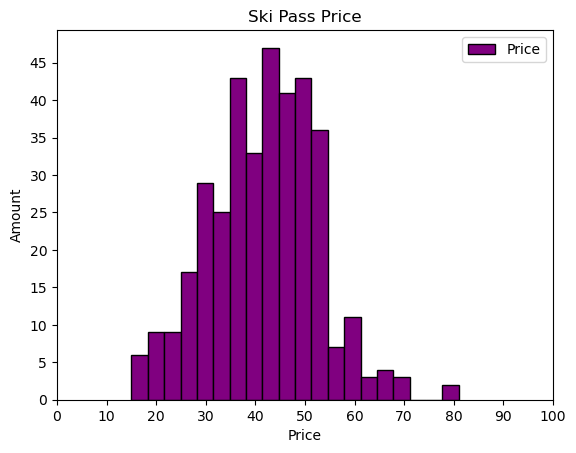

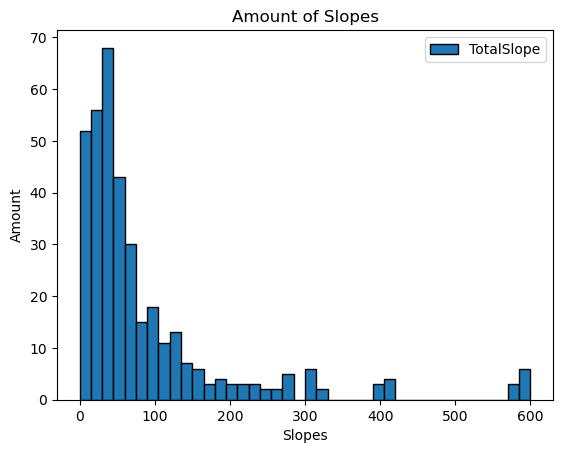

In [633]:
passplot = df[['Price']].plot(kind = 'hist', bins = 20, color = 'purple', ec = 'black')
plt.xlabel('Price')
plt.ylabel('Amount')
plt.yticks(range(0, 50, 5))
plt.xticks(range(0, 101, 10))
passplot.set_title('Ski Pass Price')
plt.show()
slopesplot = df[['TotalSlope']].plot(kind = 'hist', bins = 40, ec = 'black')
plt.xlabel('Slopes')
plt.ylabel('Amount')
slopesplot.set_title('Amount of Slopes')
plt.show()



Analyzing these two charts, we can already notice a connection between the price and the number of slopes. Only a very small number of countries have a ski pass priced at more than 60 euros, and almost similarly, only a few have more than 300 slopes.

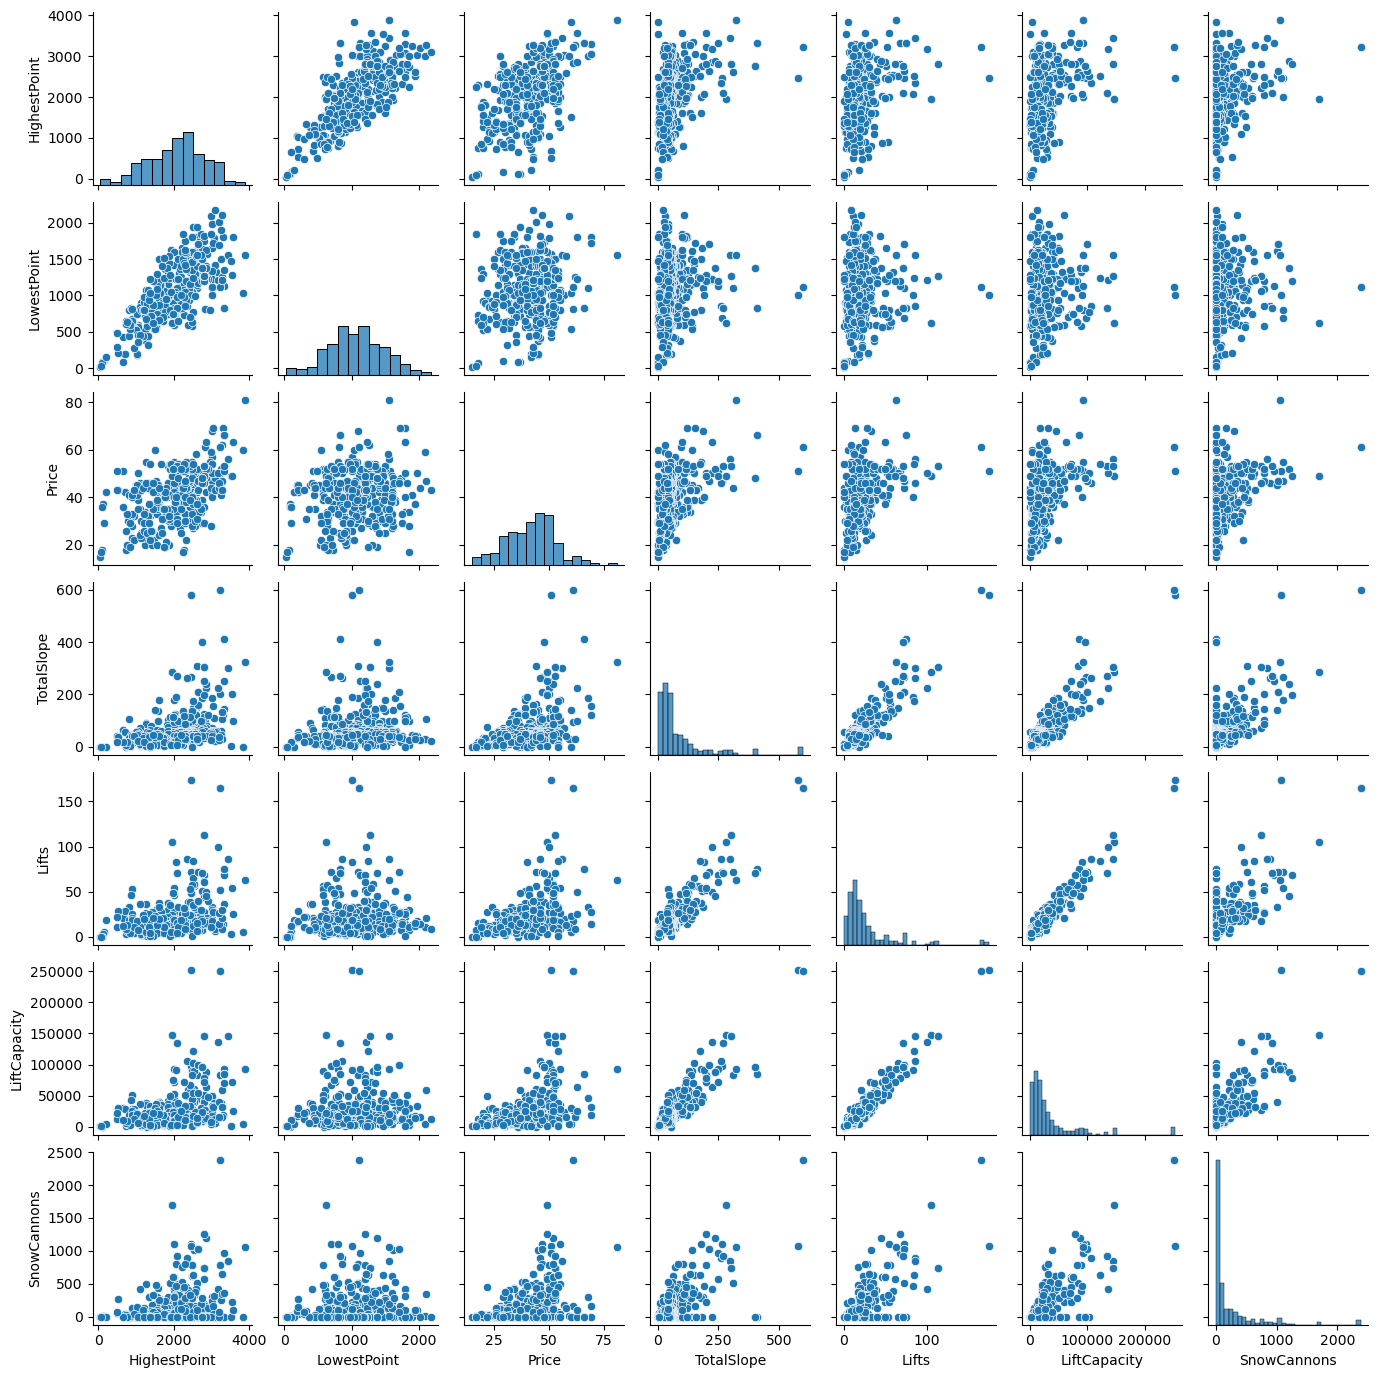

In [636]:
sns.pairplot(df, height = 2)

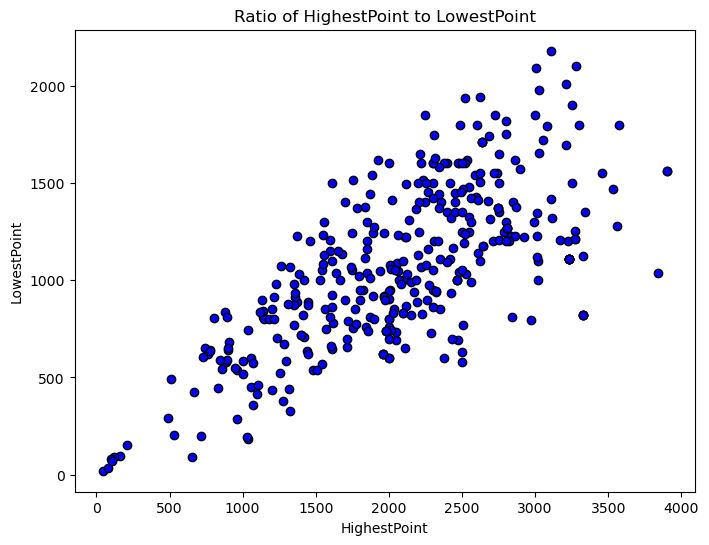

In [637]:
plt.figure(figsize=(8, 6))
plt.scatter(df['HighestPoint'], df['LowestPoint'], color='blue', edgecolor='black')

plt.title('Ratio of HighestPoint to LowestPoint')
plt.xlabel('HighestPoint')
plt.ylabel('LowestPoint')
plt.show()


# Main Hypothesis:
## Ski resorts that cost more money offer more features (number of snow cannons, slopes, lifts).

To visually test our hypothesis, we will create several graphs showing relationships across different parameters and identify any patterns. First, we will create a pie and bar charts showing the relationship between countries and the number of slopes in each country that the resort offers.

In [640]:
def sum_smth(a, parametr):
    count = 0
    for i in range(len(df['Country'])):
        if df['Country'][i] == a:
            count+=parametr[i]
    return count

The function above calculates the number of something (a parameter that can be changed) in a specific country.

In [656]:
countries = list(set(df['Country']))
new_countries = pd.DataFrame(countries, columns=['Country'])
lst = []
for i in range(len(new_countries)):
    slps = 0
    slps = sum_smth(new_countries['Country'][i], df['TotalSlope'])
    lst.append([new_countries['Country'][i], slps])
most_slides = sorted(lst, key = lambda x: x[1], reverse = True)
number = [element[1] for element in lst]
new_countries['TotalSlope'] = number

sorted_countries = new_countries.sort_values(by = 'TotalSlope', ascending=False)

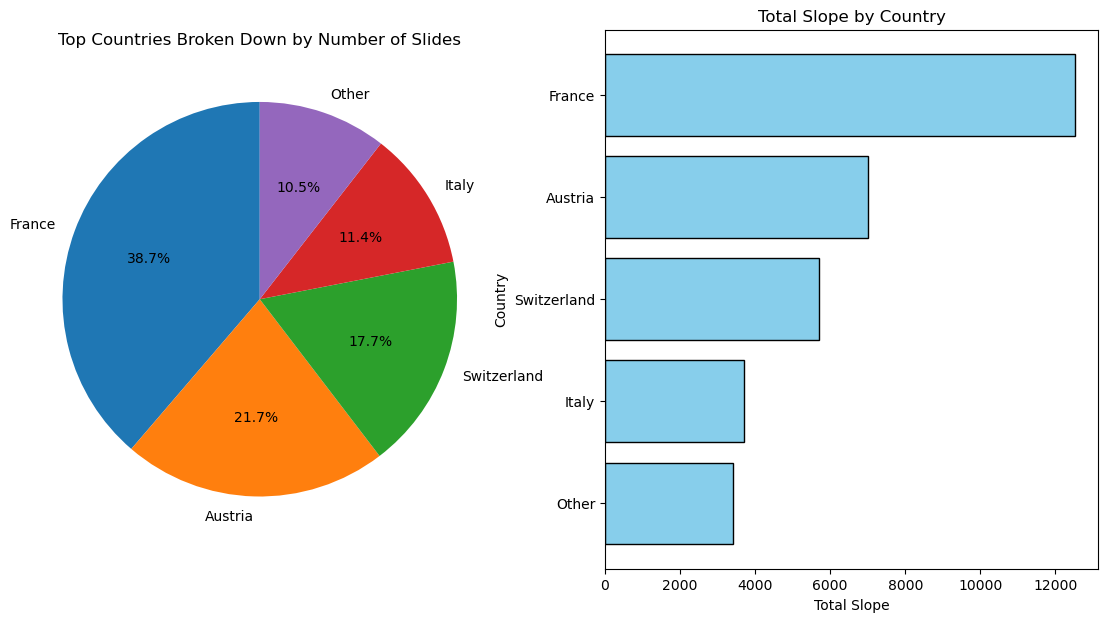

In [658]:
top_countries = sorted_countries.iloc[:4]
other = pd.DataFrame([{'Country': 'Other', 'TotalSlope': sorted_countries.iloc[4:]['TotalSlope'].sum()}])
final_data = pd.concat([top_countries, other])
figures, fg = plt.subplots(1, 2, figsize=(14, 7))

fg[0].pie(final_data['TotalSlope'], labels=final_data['Country'], autopct='%1.1f%%', startangle=90)
fg[0].set_title('Top Countries Broken Down by Number of Slides')

data_bar = final_data.sort_values(by='TotalSlope', ascending=True)
fg[1].barh(data_bar['Country'], data_bar['TotalSlope'], color = 'skyblue', edgecolor = 'black')
fg[1].set_title('Total Slope by Country')
fg[1].set_xlabel('Total Slope')
fg[1].set_ylabel('Country')

plt.show()

As we can see, France, Austria, Switzerland, and Italy dominate in terms of the number of resorts offering the highest number of slopes.

 Now let's create a bar chart and a pie chart showing the relationship between countries and the average prices of resorts in each specific country.

In [662]:
def amount(a, parametr):
    count = 0
    entries = 0
    for i in range(368):
        if df['Country'][i] == a:
            count += parametr[i]
            entries += 1
    return count//entries


The function above calculates the average number of something (a parameter that can be changed) in a specific country.

In [665]:
countries = list(set(df['Country']))
new_countries = pd.DataFrame(countries, columns=['Country'])
lst = []
for i in range(len(new_countries)):
    slps = 0
    slps = amount(new_countries['Country'][i], df['Price'])
    lst.append([new_countries['Country'][i], slps])
most_slides = sorted(lst, key = lambda x: x[1], reverse = True)
number = [element[1] for element in lst]
new_countries['Price'] = number
sorted_countries = new_countries.sort_values(by = 'Price', ascending=False)

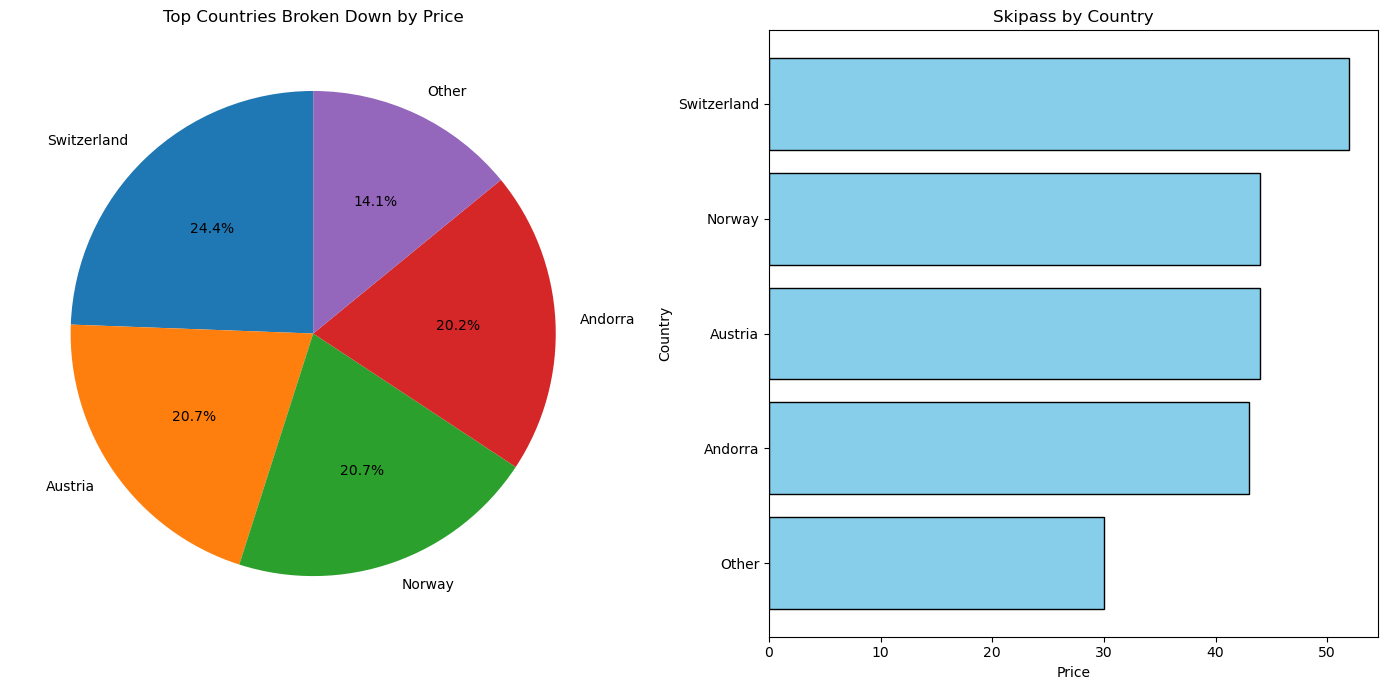

In [667]:
top_countries = sorted_countries.iloc[:4]

other = pd.DataFrame([{'Country': 'Other', 'Price': (sorted_countries.iloc[4:]['Price'].sum())//23}])
final_data = pd.concat([top_countries, other])
figures, fg = plt.subplots(1, 2, figsize=(14, 7))

fg[0].pie(final_data['Price'], labels=final_data['Country'], autopct='%1.1f%%', startangle=90)
fg[0].set_title('Top Countries Broken Down by Price')

data_bar = final_data.sort_values(by='Price', ascending=True)
fg[1].barh(data_bar['Country'], data_bar['Price'], color = 'skyblue', edgecolor = 'black')
fg[1].set_title('Skipass by Country')
fg[1].set_xlabel('Price')
fg[1].set_ylabel('Country')

plt.tight_layout()
plt.show()

We note that the countries have changed, but Switzerland and Austria are still at the top of the list. From this, we can make a small conclusion: **in Switzerland and Austria, the prices at resorts are high, but the number of slopes is also the highest there**.


To finally confirm our hypothesis, we will create three graphs showing the relationship between **price and the number of slopes, price and the number of snow cannons, and price and the number of lifts**.

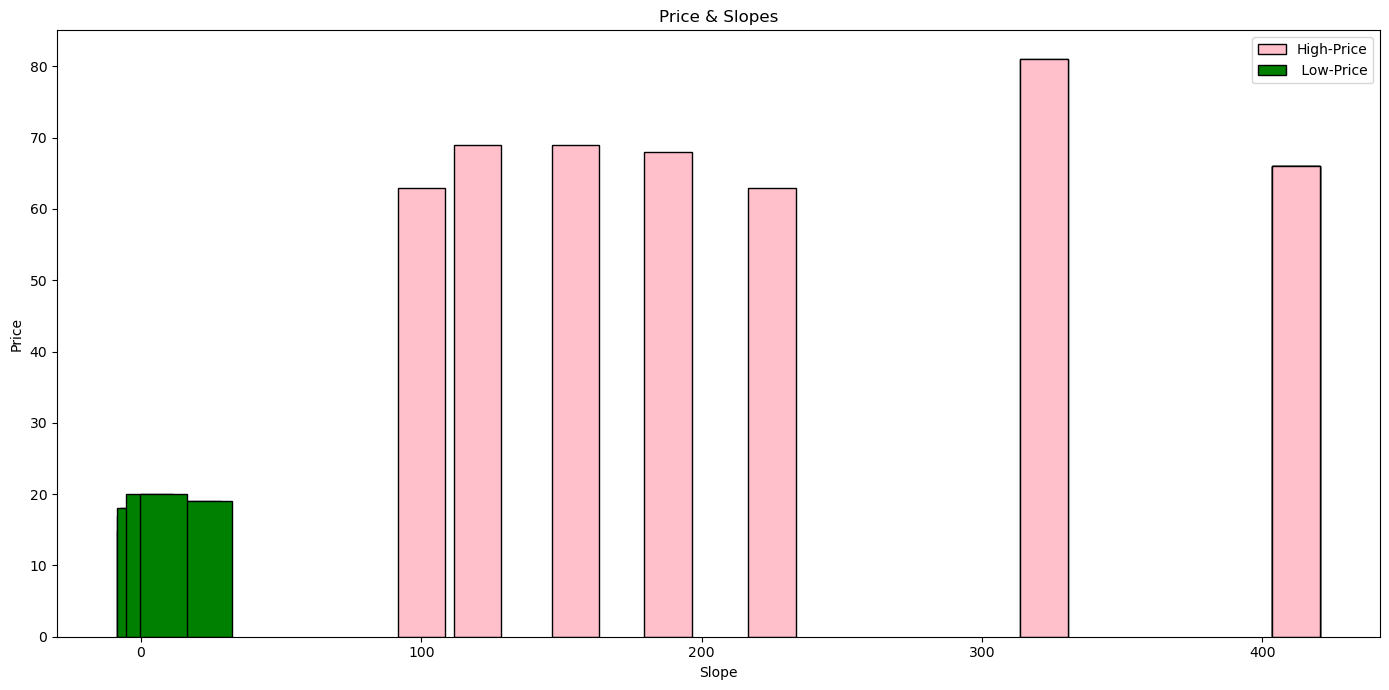

In [671]:

figures, ax = plt.subplots(figsize=(14, 7))
final_data1 = df.sort_values(by='Price', ascending=False).head(11)
final_data2 = df.sort_values(by='Price').head(11)

ax.bar(final_data1['TotalSlope'], final_data1['Price'], color = 'pink', label = 'High-Price', edgecolor = 'black', width=17)
ax.bar(final_data2['TotalSlope'], final_data2['Price'], color = 'green', label = ' Low-Price', edgecolor = 'black', width=17)

ax.set_title('Price & Slopes')
ax.set_xlabel('Slope')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()

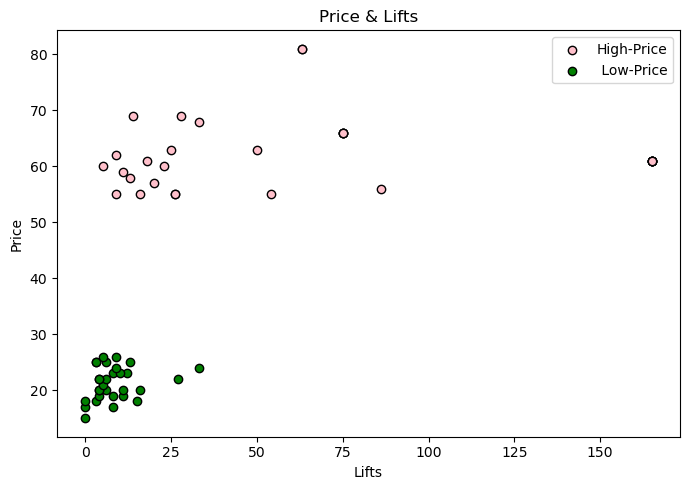

In [673]:
figures, ax = plt.subplots(figsize=(7, 5))
final_data1 = df.sort_values(by='Price', ascending=False).head(30)
final_data2 = df.sort_values(by='Price').head(30)

ax.scatter(final_data1['Lifts'], final_data1['Price'], label = 'High-Price', color = 'pink', edgecolor = 'black')
ax.scatter(final_data2['Lifts'], final_data2['Price'], label = ' Low-Price', color = 'green', edgecolor = 'black')

ax.set_title('Price & Lifts')
ax.set_xlabel('Lifts')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()

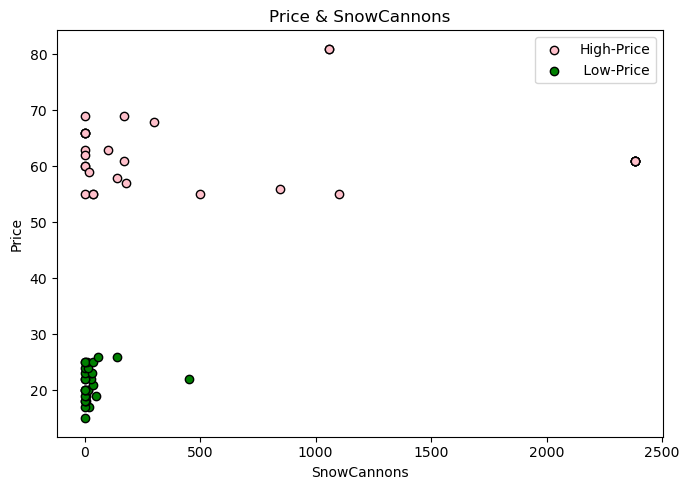

In [675]:

figures, ax = plt.subplots(figsize=(7, 5))
final_data1 = df.sort_values(by='Price', ascending=False).head(30)
final_data2 = df.sort_values(by='Price').head(30)

ax.scatter(final_data1['SnowCannons'], final_data1['Price'], label = 'High-Price', color = 'pink', edgecolor = 'black')
ax.scatter(final_data2['SnowCannons'], final_data2['Price'], label = ' Low-Price', color = 'green', edgecolor = 'black')

ax.set_title('Price & SnowCannons')
ax.set_xlabel('SnowCannons')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()

# Conclusions

Analyzing the three charts below, we come to the conclusion that the price influences the number of amenities provided by the resorts. This is most clearly visible in the chart comparing price vs. the number of slopes. Although some values align in the price vs. number of lifts chart, the overwhelming majority of high-priced resorts have a higher number of lifts. The final and less noticeable difference is seen in the price vs. number of snow cannons chart. This is likely due to the fact that expensive resorts are most often located in snowy regions or mountainous areas where snow cannons are rarely necessary because natural snowfall is sufficient. **Therefore, our hypothesis has been confirmed**.